In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [36]:
df = pd.read_csv("smartcart_customers.csv")

In [37]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [38]:
df.shape

(2240, 22)

In [39]:
df.isnull().any()

ID                     False
Year_Birth             False
Education              False
Marital_Status         False
Income                  True
Kidhome                False
Teenhome               False
Dt_Customer            False
Recency                False
MntWines               False
MntFruits              False
MntMeatProducts        False
MntFishProducts        False
MntSweetProducts       False
MntGoldProds           False
NumDealsPurchases      False
NumWebPurchases        False
NumCatalogPurchases    False
NumStorePurchases      False
NumWebVisitsMonth      False
Complain               False
Response               False
dtype: bool

Data Preprocessing

In [40]:
from sklearn.impute  import SimpleImputer
num = SimpleImputer(strategy ="median")
df[["Income"]]=num.fit_transform(df[["Income"]])

In [41]:
df.isnull().any()

ID                     False
Year_Birth             False
Education              False
Marital_Status         False
Income                 False
Kidhome                False
Teenhome               False
Dt_Customer            False
Recency                False
MntWines               False
MntFruits              False
MntMeatProducts        False
MntFishProducts        False
MntSweetProducts       False
MntGoldProds           False
NumDealsPurchases      False
NumWebPurchases        False
NumCatalogPurchases    False
NumStorePurchases      False
NumWebVisitsMonth      False
Complain               False
Response               False
dtype: bool

Feature Engineering

In [42]:

df['age'] =2026 -df['Year_Birth']

In [43]:
#customer joining date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst =True)
reference_date =df["Dt_Customer"].max()
df["Customer_tenure_days"] =(reference_date - df["Dt_Customer"]).dt.days

In [44]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [45]:
df["total_spending"] = df["MntWines"] +  df["MntFruits"]  + df["MntMeatProducts"] + df["MntFishProducts"] +  df["MntSweetProducts"] +  df["MntGoldProds"]

In [46]:
df["total_children"] = df["Kidhome"] +df["Teenhome"]

In [47]:
df["Education"].value_counts()

#undergarduate ,graduate,postgraduate

df["Education"] = df["Education"].replace({
    "Basic" : "undergraduate",
    "2n Cycle":"undergraduate",
    "graduation":"graduate",
    "PhD":"postgraduate",
    "Master":"postgraduate"
})

In [48]:
df["Education"].value_counts()

Education
Graduation       1127
postgraduate      856
undergraduate     257
Name: count, dtype: int64

In [49]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [50]:
df["Living_With"] = df["Marital_Status"].replace({
            "Married":"Partner",
            "Together":"Partner",
            "Single":"Alone",
            "Divorced":"Alone",
            "Widow":"Alone",
            "Absurd":"Alone",
            "YOLO":"Alone"})

In [51]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [52]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_tenure_days,total_spending,total_children,Living_With
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


Drop Columns

In [53]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
df_cleaned = df.drop(columns =cols)
        

In [54]:
df_cleaned.shape

(2240, 15)

In [55]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_tenure_days,total_spending,total_children,Living_With
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


Outliers

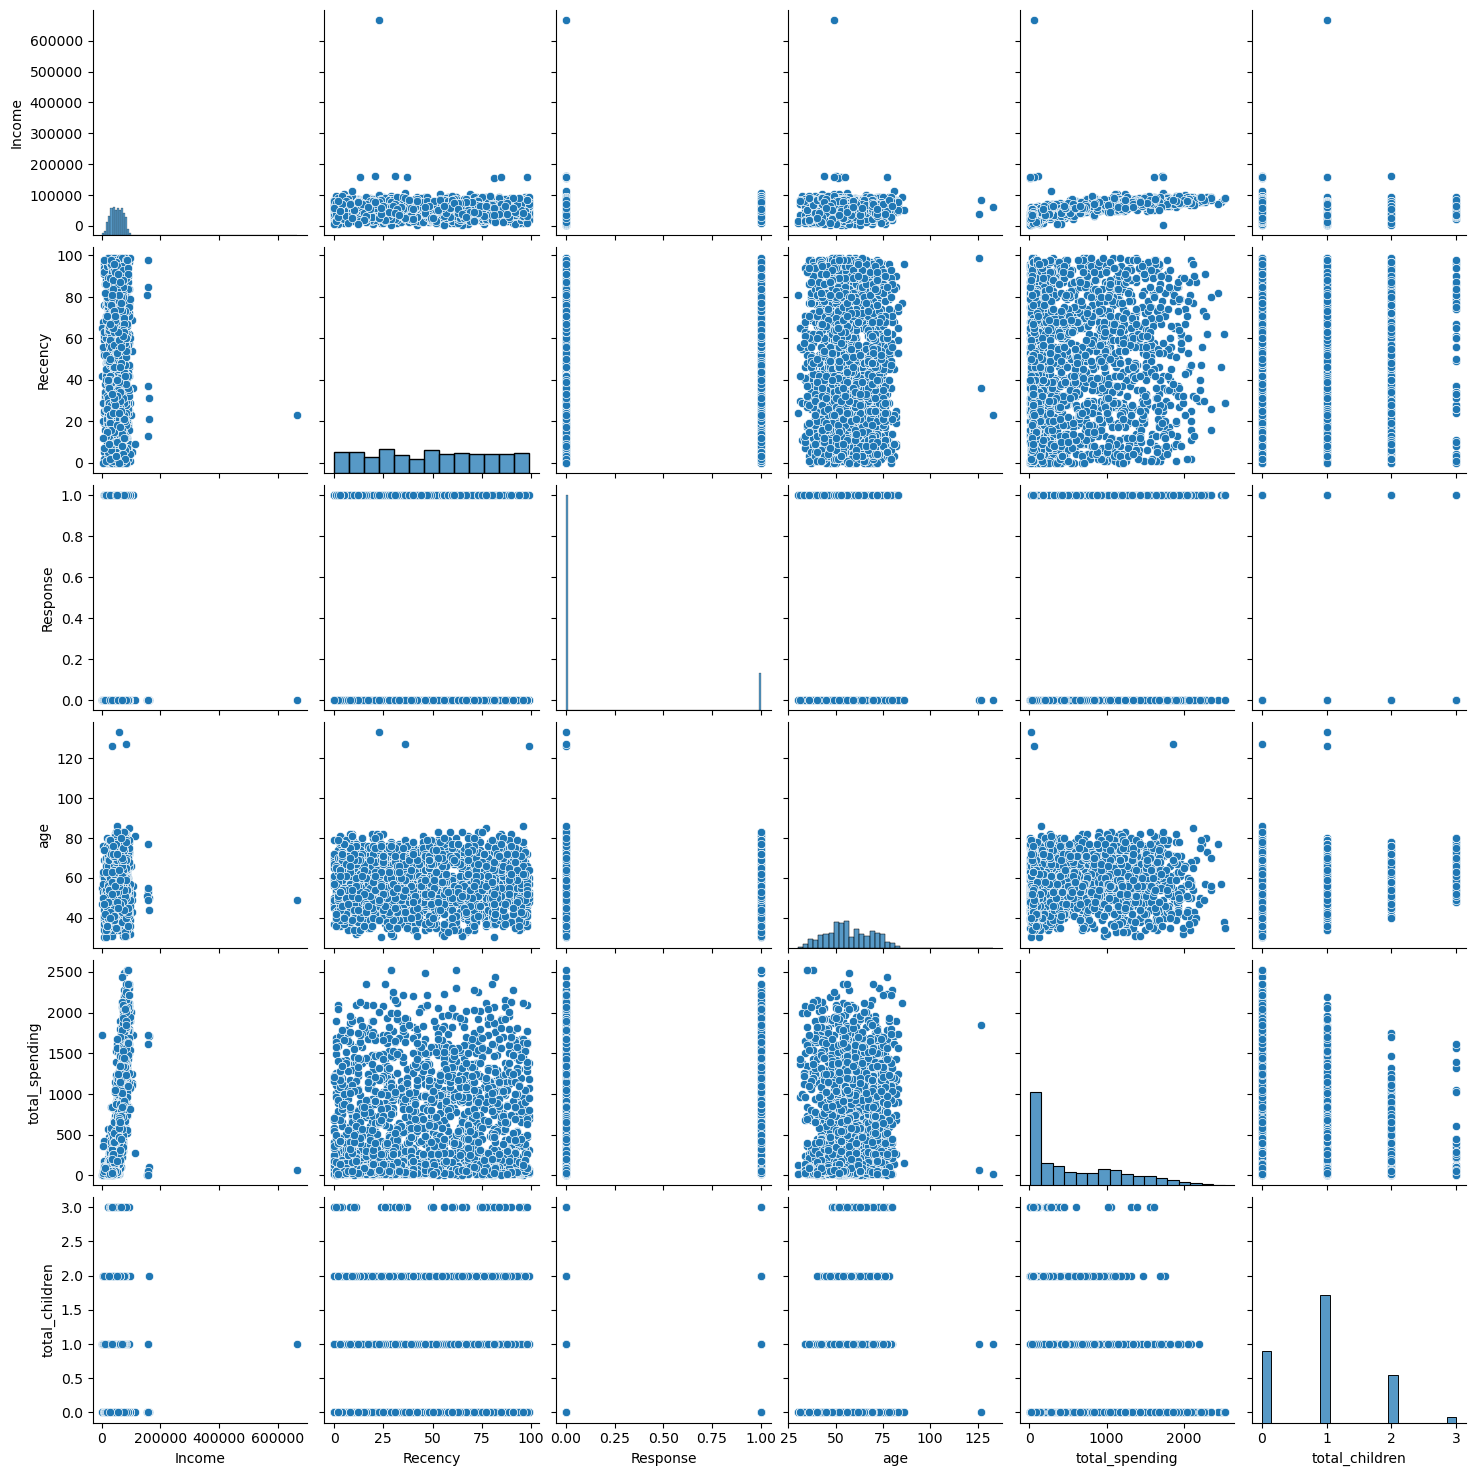

In [56]:
cols =["Income","Recency","Response","age","total_spending","total_children"]
#relative plots of some features -pair plots

sns.pairplot(df_cleaned[cols])

In [57]:
print("data size with ouliers",len(df_cleaned))

data size with ouliers 2240


In [58]:
df_cleaned = df_cleaned[df_cleaned["age"] <90]
df_cleaned = df_cleaned[df_cleaned["Income"] <600_000]
print("data size without ouliers",len(df_cleaned))

data size without ouliers 2236


In [59]:
#heat map

corr =df_cleaned.corr(numeric_only =True)

<Axes: >

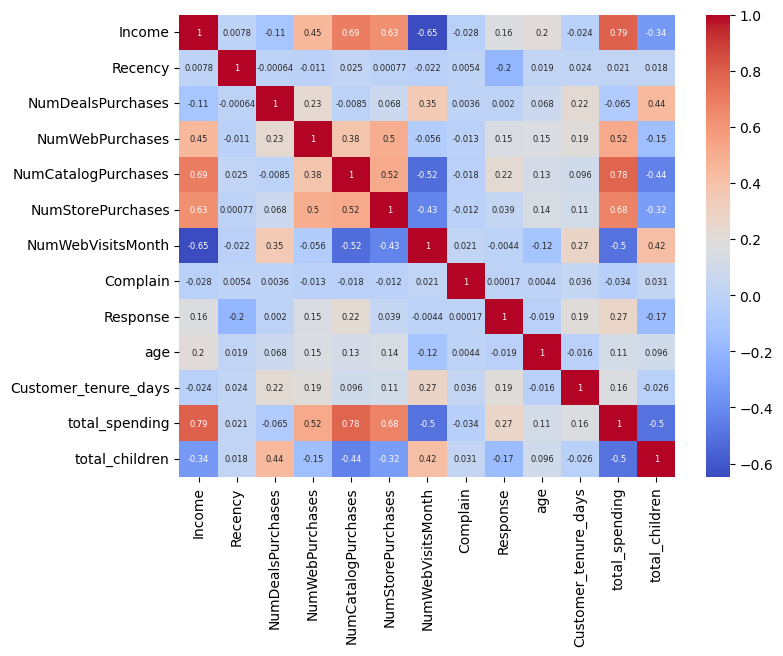

In [60]:
plt.figure(figsize =(8,6))
sns.heatmap( corr,
             annot =True,
             annot_kws ={"size":6},
             cmap ="coolwarm")

Encoding


In [63]:
from sklearn.preprocessing import OneHotEncoder

ohe  = OneHotEncoder()

cat_cols = ["Education","Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [64]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns =ohe.get_feature_names_out(cat_cols),index = df_cleaned.index)

In [65]:
enc_df.head()

,Education_Graduation,Education_postgraduate,Education_undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [67]:
df_cleaned = pd.concat([df_cleaned.drop(columns =cat_cols),enc_df],axis =1)

In [69]:
df_cleaned.shape


(2236, 18)

Scaling

In [71]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()
x = df_cleaned
x_scaled = scaler.fit_transform(x)

Visualize

In [72]:
x_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

In [74]:
x_scaled.shape

(2236, 18)

In [76]:
from sklearn.decomposition import PCA
pca = PCA(
    n_components =2)
x_pca = pca.fit_transform(x_scaled)

<Axes: >

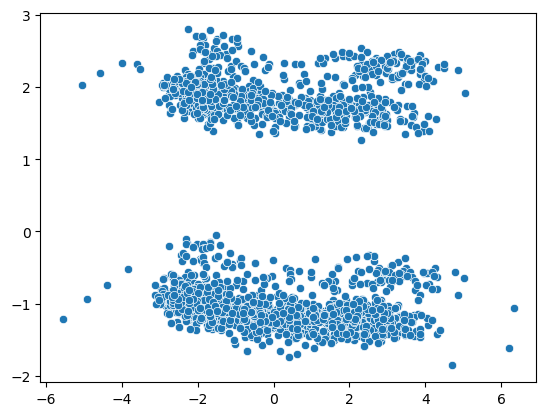

In [78]:
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1])

In [80]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

<Axes: >

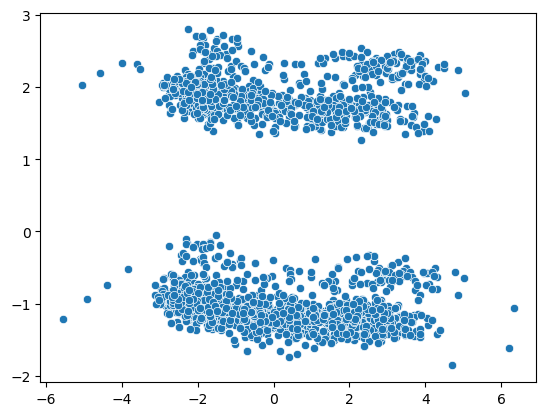

In [81]:
from sklearn.decomposition import PCA
pca = PCA(
    n_components =3)
x_pca = pca.fit_transform(x_scaled)
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1])

In [82]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

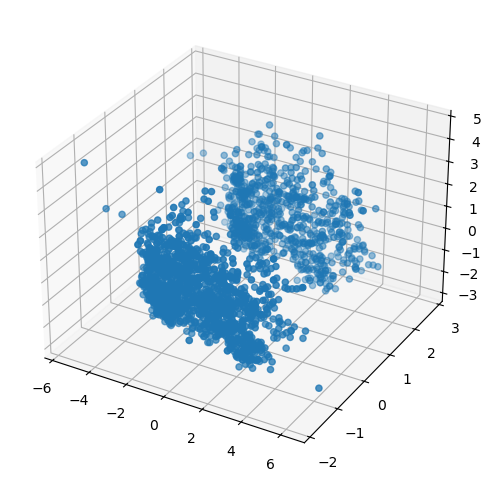

In [85]:
fig = plt.figure(figsize =(8,6))
ax =fig.add_subplot(111,projection ="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

finding k

In [91]:
#elbow method 
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss =[]
for i in range(1,11):
    kmeans =KMeans(
        n_clusters =i,
        random_state =42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)
    

In [96]:
knee =KneeLocator(range(1,11),wcss,curve ="convex",direction="decreasing")

In [97]:
optimal_k = knee.elbow

In [98]:
print(optimal_k)

4


Text(0, 0.5, 'wcss')

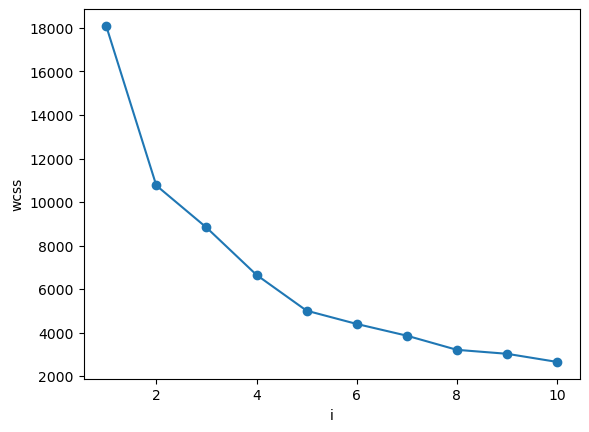

In [99]:
plt.plot(range(1,11),wcss,marker ='o')
plt.xlabel("i")
plt.ylabel("wcss")

Clustering

<Axes: >

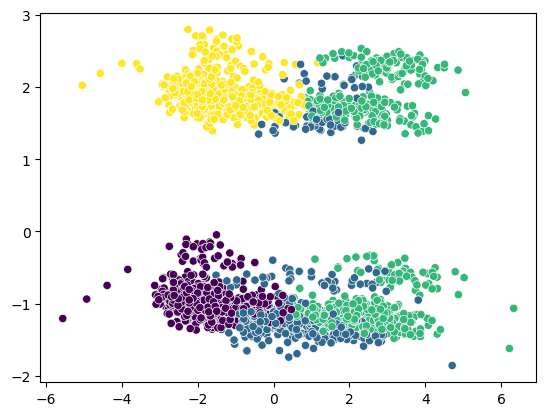

In [103]:
#kmeans clustering
kmeans = KMeans(
    n_clusters =4,
    random_state =42
)
labels = kmeans.fit_predict(x_pca)
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],c =labels)

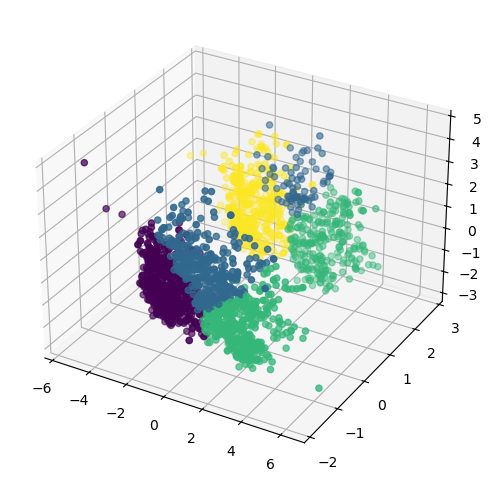

In [104]:
fig = plt.figure(figsize =(8,6))
ax =fig.add_subplot(111,projection ="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels)

In [107]:
from sklearn.cluster import AgglomerativeClustering

agg_cl = AgglomerativeClustering(n_clusters =4,
                                 linkage="ward")
labels_agg =agg_cl.fit_predict(x_pca)

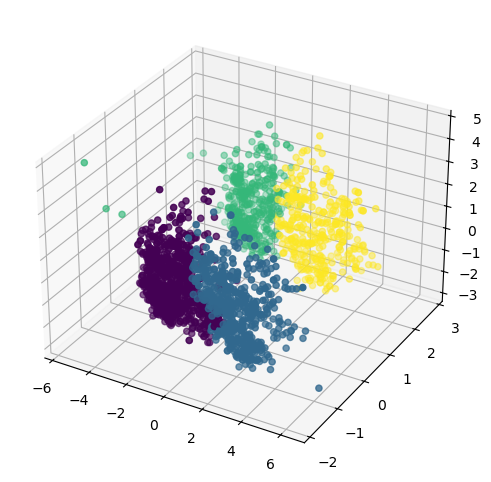

In [108]:
fig = plt.figure(figsize =(8,6))
ax =fig.add_subplot(111,projection ="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_agg)

In [109]:
from sklearn.cluster import DBSCAN

In [119]:
db = DBSCAN( eps =0.7,
             min_samples =46)
                                 
labels_db =db.fit_predict(x_pca)

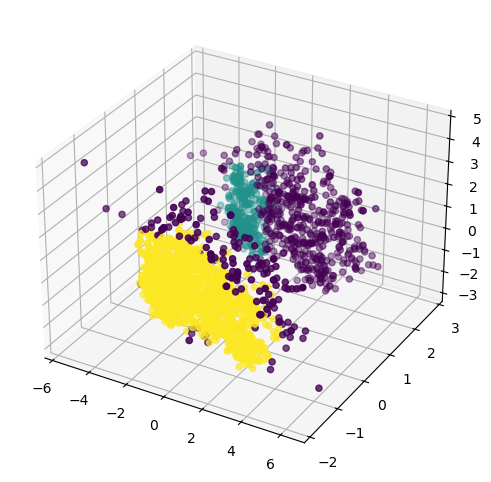

In [120]:
fig = plt.figure(figsize =(8,6))
ax =fig.add_subplot(111,projection ="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_db)

Characterization

In [121]:
df_cleaned["labels"] = labels_agg

In [123]:
df_cleaned.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_tenure_days,total_spending,total_children,Education_Graduation,Education_postgraduate,Education_undergraduate,Living_With_Alone,Living_With_Partner,labels
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='labels', ylabel='count'>

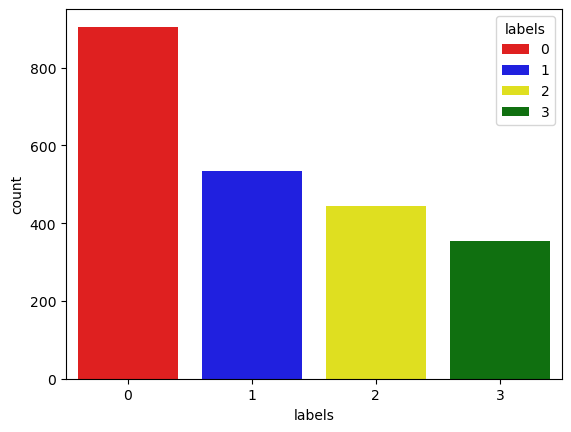

In [124]:
pal = ["red","blue","yellow","green"]
sns.countplot(x=df_cleaned["labels"],palette =pal ,hue =df_cleaned["labels"])

<Axes: xlabel='total_spending', ylabel='Income'>

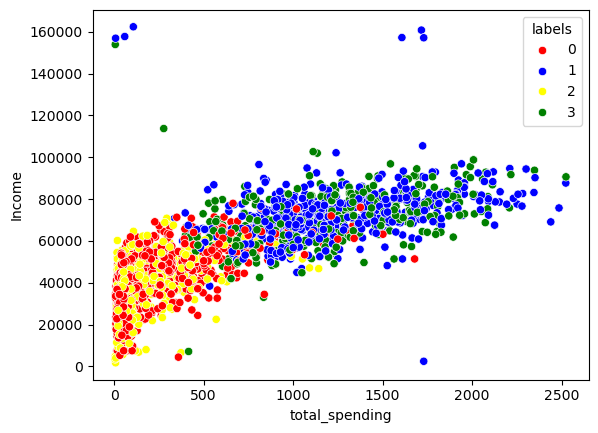

In [126]:
sns.scatterplot(x=df_cleaned["total_spending"],y=df_cleaned["Income"],hue =df_cleaned["labels"],palette =pal)

In [ ]:
cluster_summary = x.groupby(